In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

df_diabetes = pd.read_csv('../data/diabetes.csv')
df_heart    = pd.read_csv('../data/heart.csv')
df_ckd      = pd.read_csv('../data/kidney_disease.csv')

print("Diabetes:", df_diabetes.shape)
print("Heart:   ", df_heart.shape)
print("CKD:     ", df_ckd.shape)
print("All datasets loaded!")

Diabetes: (768, 9)
Heart:    (1025, 14)
CKD:      (400, 26)
All datasets loaded!


In [3]:
X_diabetes = df_diabetes.drop('Outcome', axis=1)
y_diabetes = df_diabetes['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42)

model_diabetes = RandomForestClassifier(n_estimators=100, random_state=42)
model_diabetes.fit(X_train, y_train)

y_pred = model_diabetes.predict(X_test)
y_prob = model_diabetes.predict_proba(X_test)[:, 1]

print("=== DIABETES MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.2f}")
print(classification_report(y_test, y_pred))

=== DIABETES MODEL ===
Accuracy: 0.72
AUC-ROC:  0.81
              precision    recall  f1-score   support

           0       0.79      0.78      0.78        99
           1       0.61      0.62      0.61        55

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



In [4]:
heart_features = ['age','trestbps','chol','thalach','oldpeak','cp']

X_heart = df_heart[heart_features]
y_heart = df_heart['target']

X_train, X_test, y_train, y_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42)

model_heart = RandomForestClassifier(n_estimators=100, random_state=42)
model_heart.fit(X_train, y_train)

y_pred = model_heart.predict(X_test)
y_prob = model_heart.predict_proba(X_test)[:, 1]

print("=== HEART DISEASE MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.2f}")
print(classification_report(y_test, y_pred))

=== HEART DISEASE MODEL ===
Accuracy: 0.99
AUC-ROC:  1.00
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205



In [5]:
df_ckd_clean = pd.read_csv('../data/kidney_disease.csv')

# Drop useless ID column
df_ckd_clean = df_ckd_clean.drop('id', axis=1)

# Clean up messy values
df_ckd_clean = df_ckd_clean.replace({'?': np.nan, '\t?': np.nan})

# Fix the label FIRST
df_ckd_clean['classification'] = df_ckd_clean['classification'].str.strip()
df_ckd_clean['classification'] = df_ckd_clean['classification'].map({'ckd': 1, 'notckd': 0})

# Encode text columns to numbers
for col in df_ckd_clean.columns:
    if df_ckd_clean[col].dtype == 'object':
        df_ckd_clean[col] = LabelEncoder().fit_transform(
            df_ckd_clean[col].astype(str))

# FIX: force ALL columns to numeric before median
df_ckd_clean = df_ckd_clean.apply(pd.to_numeric, errors='coerce')

# Fill missing values with median (now works because all columns are numeric)
df_ckd_clean = df_ckd_clean.fillna(df_ckd_clean.median(numeric_only=True))

# NOW separate features and label
ckd_features = [
    'age', 'bp', 'sg', 'al', 'su',
    'bgr', 'bu', 'sc',
    'sod', 'pot', 'hemo'
]

X_ckd = df_ckd_clean[ckd_features]
y_ckd = df_ckd_clean['classification']

X_train, X_test, y_train, y_test = train_test_split(
    X_ckd, y_ckd, test_size=0.2, random_state=42)

model_ckd = RandomForestClassifier(n_estimators=100, random_state=42)
model_ckd.fit(X_train, y_train)

y_pred = model_ckd.predict(X_test)
y_prob = model_ckd.predict_proba(X_test)[:, 1]

print("=== CKD MODEL ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"AUC-ROC:  {roc_auc_score(y_test, y_prob):.2f}")
print(classification_report(y_test, y_pred))

=== CKD MODEL ===
Accuracy: 1.00
AUC-ROC:  1.00
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        52

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [6]:
import joblib
import os

# Create models folder if it doesn't exist
os.makedirs('../models', exist_ok=True)

# Save all 3 models
joblib.dump(model_diabetes, '../models/model_diabetes.pkl')
joblib.dump(model_heart,    '../models/model_heart.pkl')
joblib.dump(model_ckd,      '../models/model_ckd.pkl')

print("✅ All 3 models saved successfully!")
print("Files saved:")
print("  - models/model_diabetes.pkl")
print("  - models/model_heart.pkl")
print("  - models/model_ckd.pkl")

✅ All 3 models saved successfully!
Files saved:
  - models/model_diabetes.pkl
  - models/model_heart.pkl
  - models/model_ckd.pkl


In [7]:
print("CKD feature count:", X_ckd.shape[1])
print("CKD columns:", X_ckd.columns.tolist())

CKD feature count: 11
CKD columns: ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [8]:
print("Heart features:", X_heart.shape[1], "→", X_heart.columns.tolist())
print("CKD features:", X_ckd.shape[1], "→", X_ckd.columns.tolist())

Heart features: 6 → ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp']
CKD features: 11 → ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo']


In [9]:
print(X_heart.columns.tolist())

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'cp']


In [10]:
import pandas as pd

feature_importance = pd.Series(model_heart.feature_importances_,
                               index=X_heart.columns)

print(feature_importance.sort_values(ascending=False))

thalach     0.202111
oldpeak     0.198517
cp          0.189587
chol        0.148717
age         0.144695
trestbps    0.116373
dtype: float64


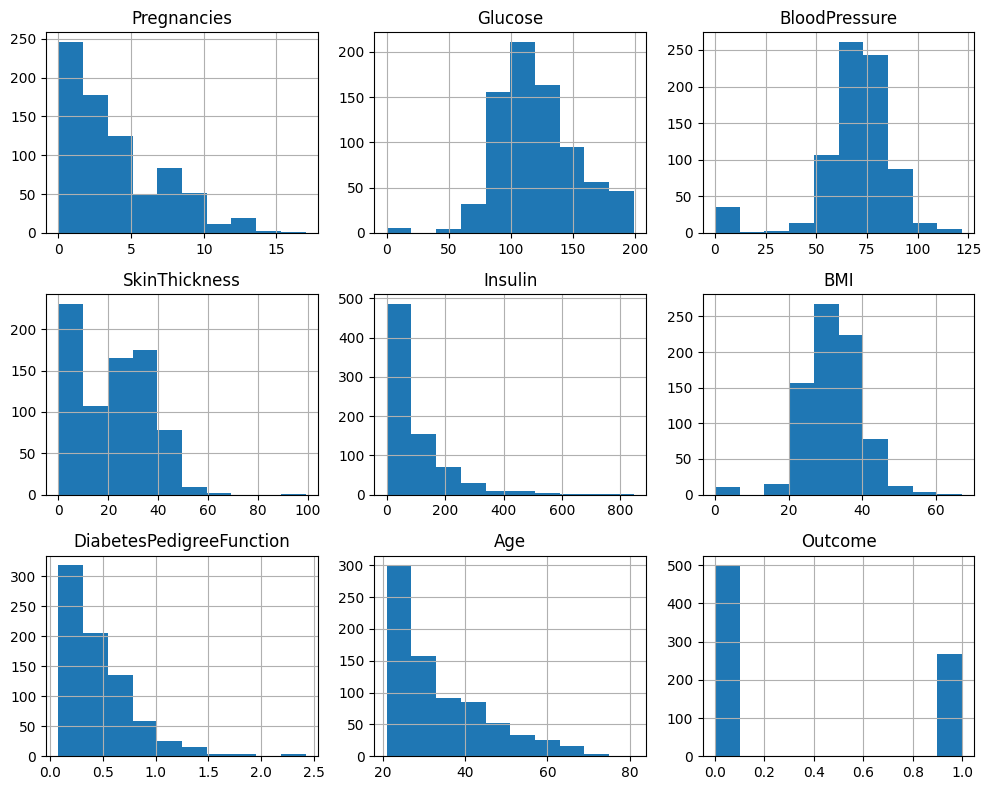

In [11]:
import matplotlib.pyplot as plt
df_diabetes.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

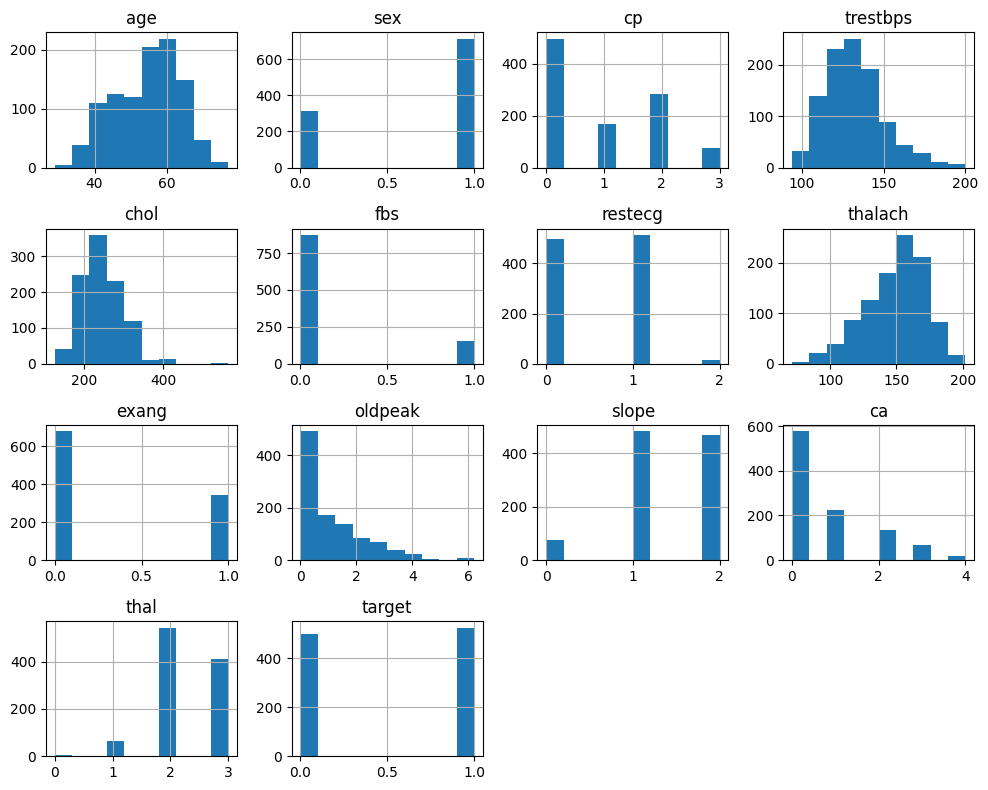

In [12]:
df_heart.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

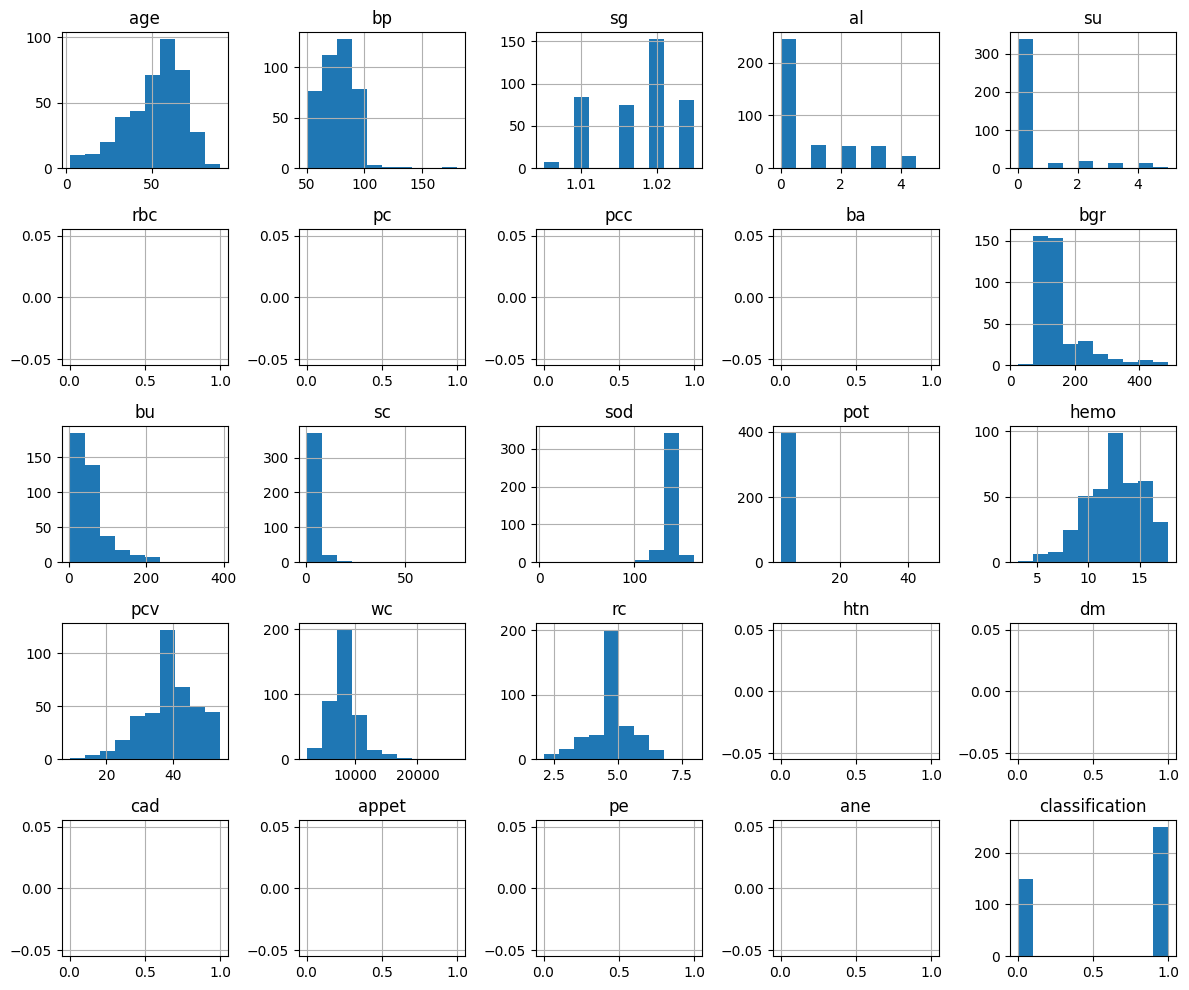

In [13]:
df_ckd_clean.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

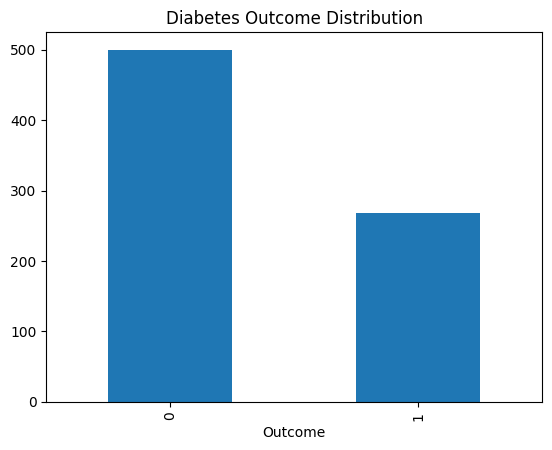

In [14]:
df_diabetes['Outcome'].value_counts().plot(kind='bar')
plt.title("Diabetes Outcome Distribution")
plt.show()

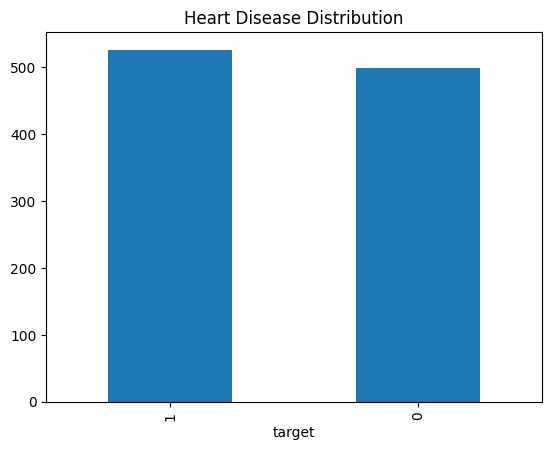

In [15]:
df_heart['target'].value_counts().plot(kind='bar')
plt.title("Heart Disease Distribution")
plt.show()

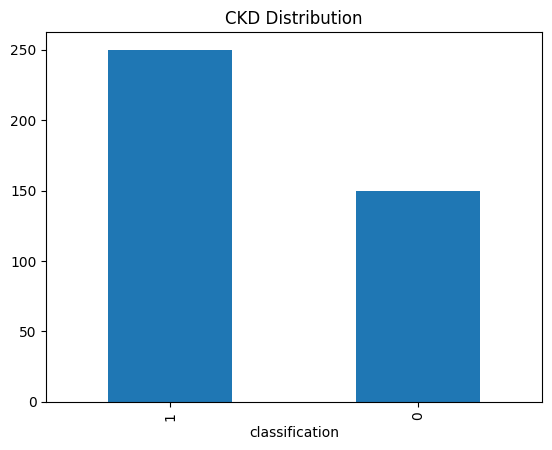

In [16]:
df_ckd_clean['classification'].value_counts().plot(kind='bar')
plt.title("CKD Distribution")
plt.show()

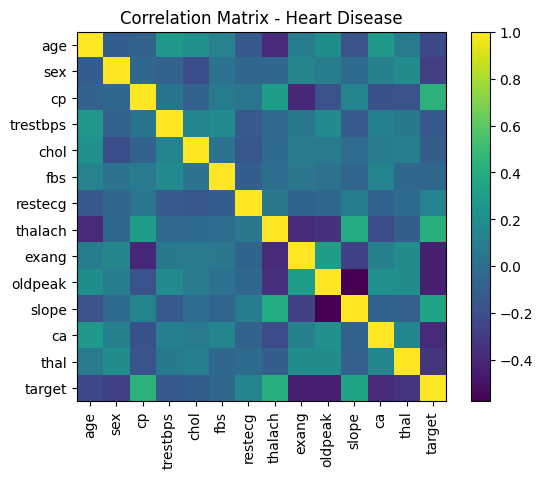

In [17]:
import matplotlib.pyplot as plt
import numpy as np

corr = df_heart.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix - Heart Disease")
plt.show()

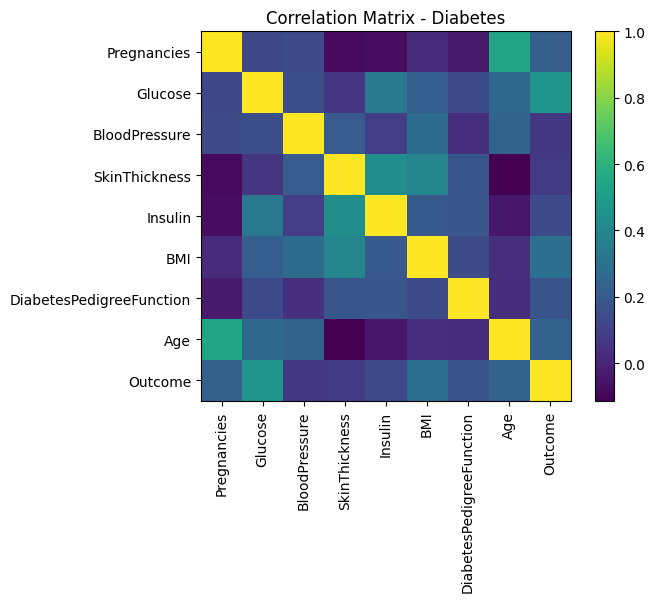

In [21]:
import matplotlib.pyplot as plt
import numpy as np

corr = df_diabetes.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix - Diabetes")
plt.show()

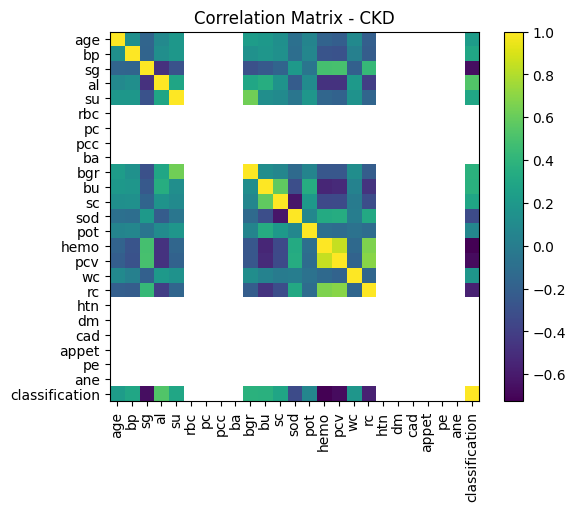

In [22]:
import matplotlib.pyplot as plt
import numpy as np

corr = df_ckd_clean.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix - CKD")
plt.show()